In [1]:
library(WGCNA)
# Allow multi-threading
enableWGCNAThreads()
library(DESeq2)
library(TCGAbiolinks)
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(ggplot2)
library(GEOquery)
library(miRBaseConverter)
library(sva)

Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust





Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor




Allowing parallel execution with up to 11 working processes.


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [8]:
# set working directory
setwd("/home/seba/github_repos/crc_weighted_network/cohort_white/count_matrices_white_byFILENAME/")

In [3]:
# Load count matrices for differential expression analysis
rna_merged_raw <- read.table("RNA_merged_counts.tsv", row.names = 1, sep="\t", header=TRUE, check.names = FALSE)
mirna_merged_raw <- read.table("miRNA_merged_counts.tsv", row.names = 1, sep="\t", header=TRUE, check.names = FALSE)

# Load metadata
metadata <- read.csv("../gdc_sample_sheet.2025-10-10.tsv", header=TRUE, sep="\t", row.names = 2)
rna_metadata <- metadata[metadata$Data.Type == "Gene Expression Quantification", ]
mirna_metadata <- metadata[metadata$Data.Type == "miRNA Expression Quantification", ]

# ensure metadata rownames are in the same order as merged_raw colnames
rna_merged_raw <- rna_merged_raw[, rownames(rna_metadata)]
mirna_merged_raw <- mirna_merged_raw[, rownames(mirna_metadata)]


In [4]:
# DESeq2 on rna data first
rna_merged_raw <- as.matrix(rna_merged_raw)
dds <- DESeqDataSetFromMatrix(countData = rna_merged_raw,
                              colData = rna_metadata,
                              design = ~ Tissue.Type)
dds <- DESeq(dds)
res <- results(dds, contrast=c("Tissue.Type", "Tumor", "Normal"))

res = res[order(res$padj), ]
res <- res[!is.na(res$padj), ]

res_ordered <- res[order(res$padj), ]
df_rna = res_ordered
df_rna$Category <- "Not significant" # Criteria can be changed
df_rna[which(df_rna$log2FoldChange > 1 & df_rna$padj <= 0.001),]$Category <- "Up-regulated"
df_rna[which(df_rna$log2FoldChange <= -1 & df_rna$padj <= 0.001),]$Category <- "Down-regulated"

df_rna <- df_rna[df_rna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1762 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [5]:
# DESeq2 on mirna data now
mirna_merged_raw <- as.matrix(mirna_merged_raw)
dds_mirna <- DESeqDataSetFromMatrix(countData = mirna_merged_raw,
                              colData = mirna_metadata,
                              design = ~ Tissue.Type)
dds_mirna <- DESeq(dds_mirna)
res_mirna <- results(dds_mirna, contrast=c("Tissue.Type", "Tumor", "Normal"))
res_mirna = res_mirna[order(res_mirna$padj), ]
res_mirna <- res_mirna[!is.na(res_mirna$padj), ]

res_mirna_ordered <- res_mirna[order(res_mirna$padj), ]
df_mirna = res_mirna_ordered
df_mirna$Category <- "Not significant" # Criteria can be changed
df_mirna[which(df_mirna$log2FoldChange > 1 & df_mirna$padj <= 0.001),]$Category <- "Up-regulated"
df_mirna[which(df_mirna$log2FoldChange <= -1 & df_mirna$padj <= 0.001),]$Category <- "Down-regulated"

df_mira <- df_mirna[df_mirna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 36 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [6]:
# write rna and mirna results to tsv files
write.table(df_rna, file="DESeq2_RNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)
write.table(df_mirna, file="DESeq2_miRNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)

In [25]:
vsd <- vst(dds, blind = TRUE)
pca <- prcomp(t(assay(vsd)), scale. = FALSE)
percentVar <- (pca$sdev^2) / sum(pca$sdev^2)

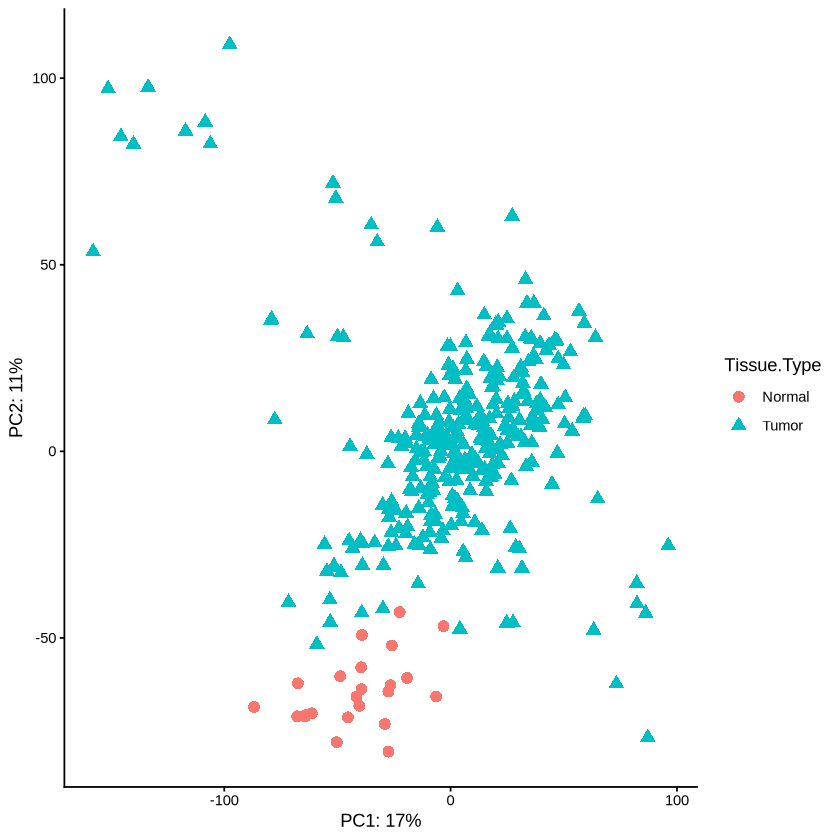

In [26]:
pca_df <- data.frame(
  PC1 = pca$x[,1],
  PC2 = pca$x[,2],
  rna_metadata
)

ggplot(pca_df, aes(PC1, PC2,
                   color = Tissue.Type,
                   shape = Tissue.Type)) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

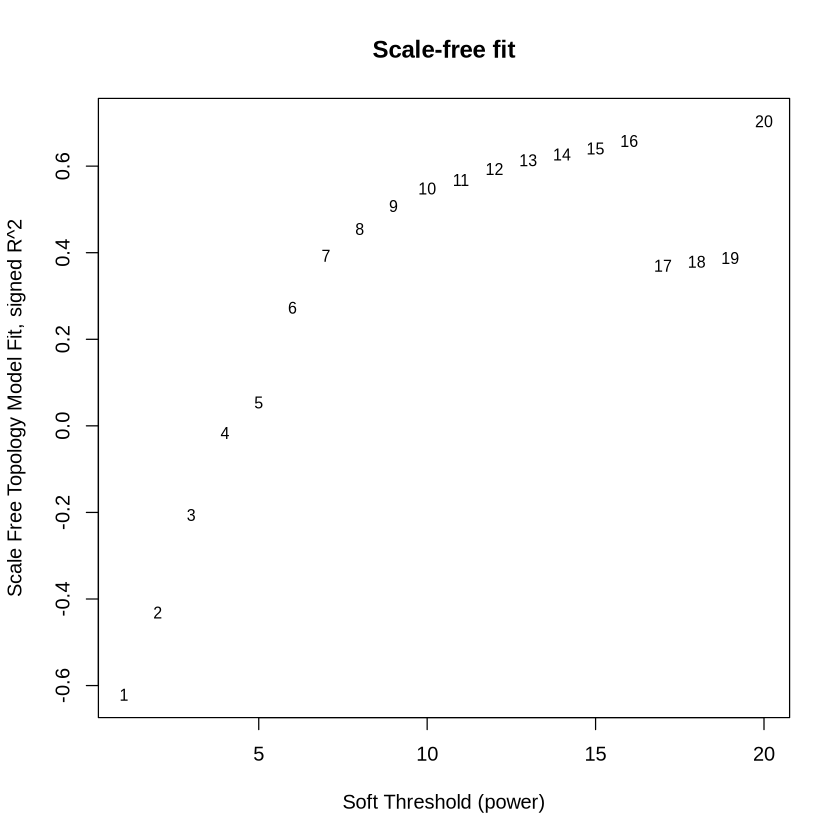

In [11]:
# Load the pre-computed WGCNA modules of RNA pooled
sft <- readRDS("../rna_pooled/softThreshold_sft.rds")
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line

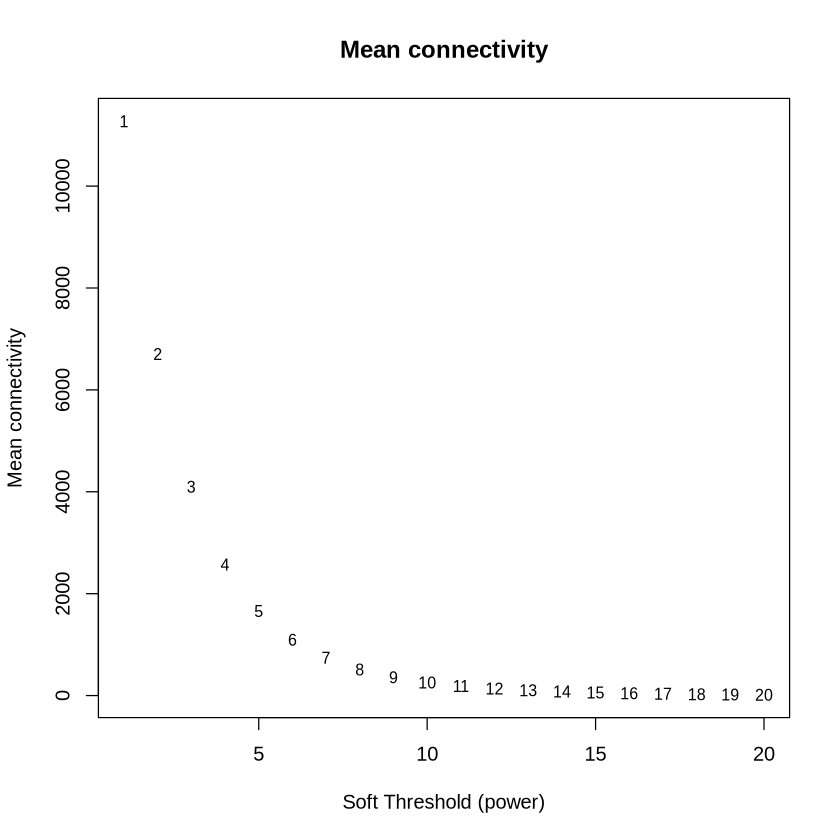

In [12]:
meanK <- sft$fitIndices[,5]  # mean connectivity

plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)

Warning message in cor(MEs, traits_num, use = "p"):
“the standard deviation is zero”


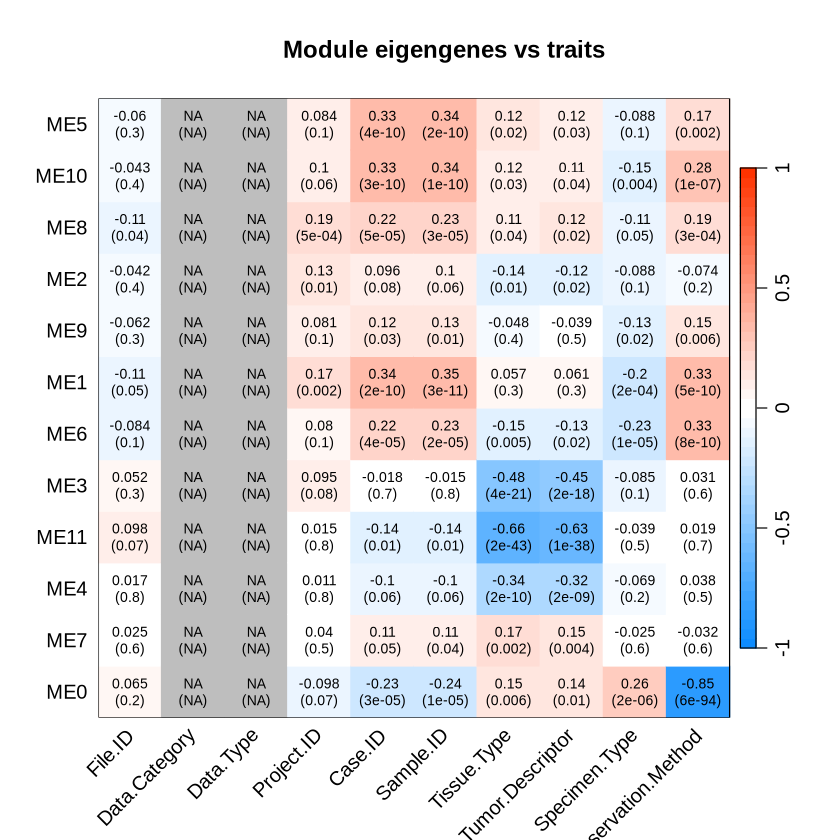

In [17]:
# module eigengene correlation table
MEs <- readRDS("../rna_pooled/MEs.rds")
traits <- readRDS("../rna_pooled/datTraits_clean.rds")

# Asegurar orden idéntico
common <- intersect(rownames(MEs), rownames(traits))
MEs <- MEs[common, ]
traits <- traits[common, ]

traits_num <- traits
  for (cn in colnames(traits_num)) {
    if (!is.numeric(traits_num[[cn]])) traits_num[[cn]] <- as.numeric(as.factor(traits_num[[cn]]))
  }

# Correlaciones
MEtraitCor <- cor(MEs, traits_num, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Texto para el heatmap
textMatrix <- paste0(
  signif(MEtraitCor, 2), "\n(",
  signif(MEtraitPvalue, 1), ")"
)
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = colnames(traits),
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1,1),
  main = "Module eigengenes vs traits"
)